In [10]:

!git clone https://github.com/MartinsOluwatobi/CV-Learning-Journal-.git
import sys
import os

# Check if the folder exists to avoid errors
repo_path = '/content/CV-Learning-Journal-/Faster RCNN'
if repo_path not in sys.path:
    sys.path.append(repo_path)


fatal: destination path 'CV-Learning-Journal-' already exists and is not an empty directory.


In [12]:
from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image
import shutil
from sklearn.model_selection import train_test_split
import pandas as pd
import torchvision.transforms as transforms 
from torch.utils.data import Dataset, DataLoader
import torch
import cv2 as cv
import matplotlib.pyplot as plt
from FasterRCNN import FasterRCNN
from LossFunction import Encode_rpn_target_and_label,rpn_loss,final_rcnn_loss, Encode_final_target_label 
from Backbone import FeatureExtractor
from RegionProposalNetwork import RegionProposalNetwork
from RoiPooling import RoIPooling

ModuleNotFoundError: No module named 'RoiPooling'

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = '/content/drive/MyDrive/Colab Notebooks/data'


In [13]:
annotation,Images = [],[]
for root, dirs, files in os.walk(file_path):
    for file in files:
        if file.endswith('.xml'):
            sample_dir = os.path.join(root,file)
            try:
               xml_root = ET.parse(sample_dir).getroot()
            except ET.ParseError as e:
               continue
            annotation.append(sample_dir)
        if file.endswith(('.jpg','.png', '.jpeg')):
            sample_dir = os.path.join(root,file)
            Images.append(sample_dir)
sorted_annotation = sorted(annotation)
sorted_Images  = sorted(Images)
annotaion_train, annotation_test, Image_train, Image_test = train_test_split(sorted_annotation, sorted_Images[:-2], test_size= 0.2,  random_state=42, shuffle = True)
splits = { 'Train': (annotaion_train, Image_train),
          'Val':(annotation_test, Image_test)}


In [20]:
class CustomDataset(Dataset):
    def __init__(self,data, image_size = (224,224), augment= False ):
        self.data = data
        if augment:
            self.transform = transforms.Compose([
                                                 transforms.Resize((224,224)),
                                                 transforms.RandomHorizontalFlip(),
                                                 transforms.ToTensor(),
                                                 transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])
        else:
            self.transform = transforms.Compose([
                                                 transforms.Resize((224,224)),
                                                 transforms.ToTensor(),
                                                 transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])
        self.label_map = {
            'with_mask':1,
            'without_mask':0,
            'mask_weared_incorrect':1}
    
    def __getitem__(self,idx):
        img_path, labels, boxes = self.data[idx]
        img = Image.open(img_path).convert('RGB')
        init_img_width, init_img_height = img.size 
        width_scale = 224/ init_img_width
        height_scale = 224/ init_img_height
        img = self.transform(img)
        scaled_boxes = [(x1*width_scale,y1*height_scale, x2*width_scale,y2 * height_scale)  
               for x1,y1,x2,y2 in boxes]
        
        label = [self.label_map[l] for l in labels]
        return img, {'boxes': torch.tensor(scaled_boxes, dtype= torch.float32), 'target': torch.tensor(label, dtype= torch.long)}
    
    def __len__(self):
        return len(self.data)
        

def DataExtraction(dir):
    row = []
    xml_files_path = os.path.join(dir,'Annotation')
    xml_files = [f for f in os.listdir(xml_files_path) if f.endswith('.xml')]
    for xml in xml_files:
        xml = os.path.join(xml_files_path, xml) 
        try:
            root = ET.parse(xml).getroot()
        except ET.ParseError as e:
            continue
        filename = root.find('filename').text
        img = f'{str(dir)}/Image/{filename}'
        labels = [obj.find('name').text for obj in root.findall('object')]
        boundingbox = [(int(obj.find('bndbox').find('xmin').text),
                    int(obj.find('bndbox').find('ymin').text),
                    int(obj.find('bndbox').find('xmax').text),
                    int(obj.find('bndbox').find('ymax').text)) for obj in root.findall('object') ]
        row.append([img,labels, boundingbox])
    return row 

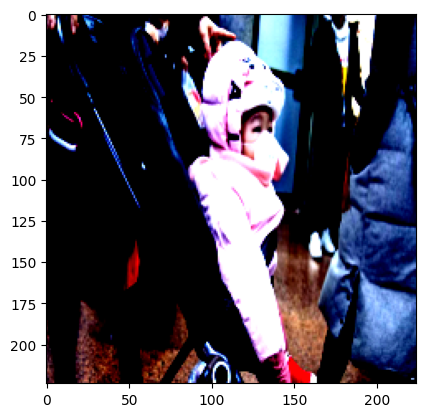

In [ ]:
dir_train = file_path + '/Train'
dir_test = file_path + '/Val'
raw_data_train = DataExtraction(dir_train)
raw_data_test = DataExtraction(dir_test)
data_train = CustomDataset(raw_data_train, augment= True)
data_test = CustomDataset(raw_data_test, augment= False)
a = next(iter(data_test))
sample_image= a[0].permute(1,2,0)
x1,y1,x2,y2 = a[1]['boxes']
cv.rectangle(sample_image,(x1,y1),(x2,y2),(0,0,255),2)
plt.imshow(sample_image)

In [23]:
def collate_fn(batch):
    """
    batch: list of (image_tensor, target_dict) tuples
    Returns images stacked as a tensor, targets left as a list of dicts.
    """
    images  = torch.stack([item[0] for item in batch])  # (B, C, H, W) — safe, all same size
    targets = [item[1] for item in batch]               # list of dicts — NOT stacked
    return images, targets


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_dataloader = DataLoader(data_train,batch_size=16,shuffle = True, collate_fn= collate_fn )
test_dataloader = DataLoader(data_test, batch_size= 16, collate_fn=collate_fn)
epochs = 1

model = FasterRCNN(num_classes=2, image_shape=(224,224)).to(device)
optimizer = torch.optim.SGD(model.parameters(),
                            lr = 0.001)
model.train()
for epoch in range(epochs):
  epoch_loss = 0
  for images,target_dict in train_dataloader:
      images = images.to(device)
      optimizer.zero_grad()
      final_cls, final_delta,proposal_boxes,rpn_reg_layer, rpn_cls, anchors, batch_idx= model(images)
      ground_truth = [t['boxes'].to(device) for t in target_dict]
      gt_labels = [t['target'].to(device) for t in target_dict]
      batch_rpn_label, batch_rpn_target = [],[]
      batch_size = images.shape[0]
      for i in range(batch_size):
          mask = batch_idx==i
          anchor = anchors[mask]
          gt_box = ground_truth[i]
          labels, target = Encode_rpn_target_and_label(anchor,ground_truth[i])
          batch_rpn_label.append(labels)
          batch_rpn_target.append(target)
      rpn_label = torch.cat(batch_rpn_label)
      rpn_target = torch.cat(batch_rpn_target)
      rpn_cls_loss, rpn_delta_loss = rpn_loss(rpn_cls,rpn_reg_layer,rpn_label,rpn_target)


      batch_final_label, batch_final_delta = [], []
      batch_final_cls,   batch_final_reg   = [], []   

      # build a per-image offset into the flat proposal tensor
      offsets = [0]
      for i in range(batch_size - 1):
          offsets.append(offsets[-1] + (batch_idx == i).sum().item())

      for i in range(batch_size):
          mask = batch_idx == i
          idx, final_label, final_delta_t = Encode_final_target_label(
              proposal_boxes[mask], ground_truth[i], gt_labels[i]
          )
          batch_final_label.append(final_label)
          batch_final_delta.append(final_delta_t)

          # slice model outputs using the same idx, offset into flat tensor
          global_idx = idx + offsets[i]
          batch_final_cls.append(final_cls[global_idx])
          batch_final_reg.append(final_delta[global_idx])

      final_labels  = torch.cat(batch_final_label)
      final_deltas  = torch.cat(batch_final_delta)
      sampled_cls   = torch.cat(batch_final_cls)    
      sampled_reg   = torch.cat(batch_final_reg)    

      final_cls_loss, final_reg_loss = final_rcnn_loss(sampled_cls, sampled_reg, final_labels, final_deltas)
      sampled_cls, sampled_reg, final_labels, final_deltas

      loss = rpn_cls_loss + rpn_delta_loss + final_cls_loss +final_reg_loss
      epoch_loss += loss.item()

      loss.backward()
      optimizer.step()  
  epoch_loss /= len(train_dataloader)
  print (f'The loss at {epoch} is {epoch_loss}')

AttributeError: 'float' object has no attribute 'item'